In [ ]:
import os
import time
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # supress warnings about CPU, namely that it is not using AVX2; 'CPP' stands for C++ (because tensorflow is written in C++)
os.environ['TF_CPP_MIN_VLOG_LEVEL'] = '2' # supress verbose logging
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0' # supress warnings about oneDNN (Intel's Deep Neural Network library)

import numpy as np 
import matplotlib.pyplot as plt 
from tensorflow.keras.datasets import cifar10 

# time it, improve it with a decorator
def timer(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(f"Time taken: {end - start}")
        return result
    return wrapper


Time taken: 3.4202938079833984
(50000, 32, 32, 3)
[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]
(50000, 1)
[6]


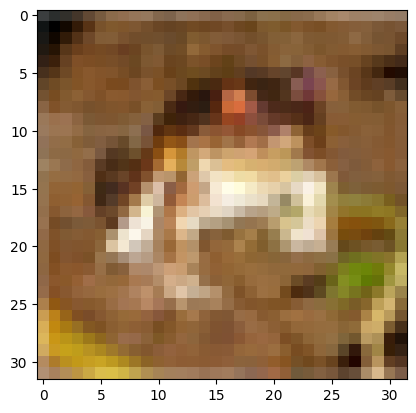

In [68]:
@timer # can only be applied to a function (def) or a class (class)

def load_data():
    (X_train, y_train), (X_test, y_test) = cifar10.load_data() # 'X' is capitalized because it is a matrix, 'y' is lowercase because it is a vector

    return (X_train, y_train), (X_test, y_test)

(X_train, y_train), (X_test, y_test) = load_data()
print(X_train.shape)
print(X_train[0])
plt.imshow(X_train[0])
print(y_train.shape)
print(y_train[0])

In [69]:
# %%time 
# # whole cell will be timed, must be on line 1 of a cell; there cannot be a statement after
# # timing methods
# (X_train, y_train), (X_test, y_test) = cifar10.load_data()
# y_train = y_train.flatten()

# %time # before function call
# (X_train, y_train), (X_test, y_test) = cifar10.load_data() 

# %timeit y_train.flatten() # runs in a loop, return an average


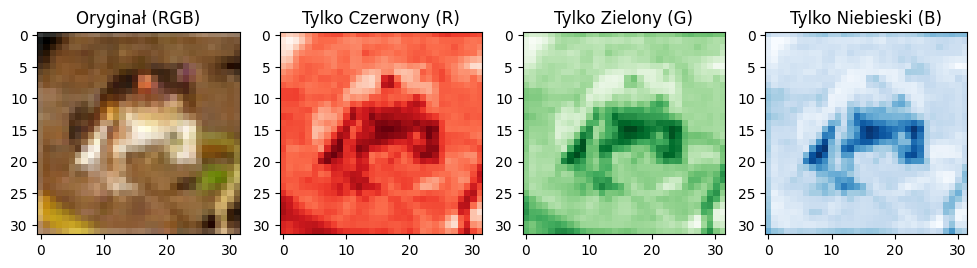

In [70]:
image = X_train[0] # Twoja żaba (32, 32, 3)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

# Główne zdjęcie (nałożone RGB)
axes[0].imshow(image)
axes[0].set_title("Oryginał (RGB)")

# Zobacz tylko kanał Czerwony (R) - shape: (32, 32)
axes[1].imshow(image[:, :, 0], cmap='Reds') 
axes[1].set_title("Tylko Czerwony (R)")

# Zobacz tylko kanał Zielony (G) - shape: (32, 32)
axes[2].imshow(image[:, :, 1], cmap='Greens')
axes[2].set_title("Tylko Zielony (G)")

# Zobacz tylko kanał Niebieski (B) - shape: (32, 32)
axes[3].imshow(image[:, :, 2], cmap='Blues')
axes[3].set_title("Tylko Niebieski (B)")

plt.show()


In [71]:
import pandas as pd

one_channel_matrix = pd.DataFrame(image[0:10,0:10,1])
display(one_channel_matrix)

,0,1,2,3,4,5,6,7,8,9
0,62,46,48,54,73,91,107,110,117,120
1,20,0,8,27,51,82,89,86,87,79
2,24,7,27,50,72,92,93,82,77,78
3,25,20,54,63,70,74,72,62,68,84
4,32,32,65,79,77,77,78,74,72,88
5,48,53,73,82,88,84,84,77,70,82
6,69,75,85,84,88,83,74,74,83,94
7,82,76,90,97,88,81,90,89,86,89
8,100,82,91,87,81,82,85,85,80,97
9,120,112,114,100,89,86,86,91,97,97


<Axes: >

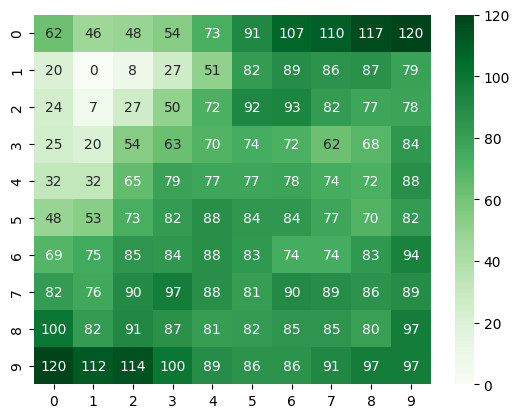

In [72]:
import seaborn as sns

sns.heatmap(one_channel_matrix, annot=True, fmt='d', cmap='Greens')

In [73]:
print(y_train.shape) # matrix is easier to manipule than a simple array
display(y_train[:,0])
y_train = y_train.flatten()
print(y_train.shape)

(50000, 1)


array([6, 9, 9, ..., 9, 1, 1], dtype=uint8)

(50000,)


In [74]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

num_classes = 10

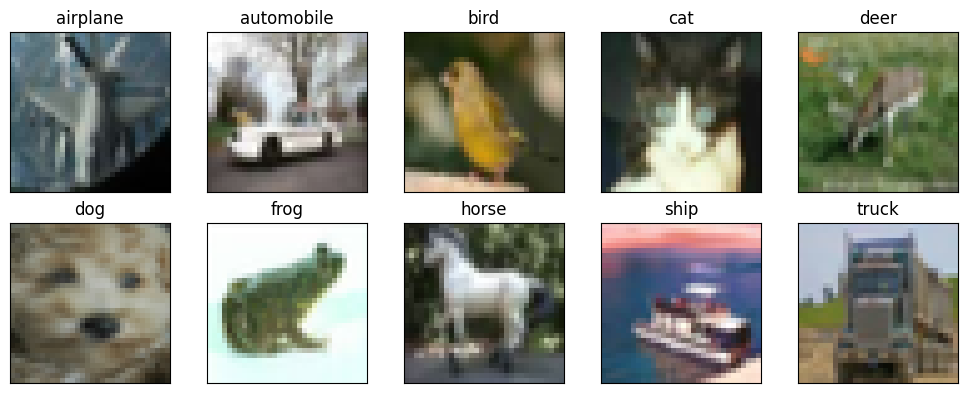

In [76]:
fig = plt.figure(figsize=(10, 4))

for i in range(num_classes):
    ax = fig.add_subplot(2, 5, i + 1, xticks=[], yticks=[])

    idx = np.where(y_train == i)[0] # np.where() return a tuple of on array

    img_num = np.random.choice(idx)

    im = X_train[img_num]
    ax.imshow(im)
    ax.set_title(class_names[i], fontsize=12)

plt.tight_layout()
plt.show()